In [1]:
import re
import time
import shutil

import nibabel as nib
import numpy as np
import colorcet as cc
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib

from nilearn.masking import apply_mask, unmask
from nilearn.image import math_img, high_variance_confounds
from scipy.interpolate import interp1d

# Reportlab for pdf 

from reportlab.pdfbase import pdfmetrics
from reportlab.lib.utils import ImageReader
from reportlab.pdfgen import canvas

/home/jmariani/miniconda3/envs/JCmri/lib/python3.12/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


# Generating the processing folder

## Parameters

In [3]:
root_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/sample_masks/mace/')
root_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*pose-vol.*.tsv$', x.name)])

data_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/01_avg-dB-registered/')

regressors_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/regressors/')

print(f'We found {len(root_dir)} files\n\n')

for x in root_dir:
    print(f'{x.name}')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/processing/')

We found 52 files


sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230328b_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230329a_ses-1MEDISOses1_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230329b_ses-1CPTses2_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230330a_ses-1CPTses3_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230331a_ses-1CPTses4_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230331b_ses-1CPTses4_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230405a_ses-1MEDISOses2_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230405b_ses-1MEDISOses2_task-rest_acq-3Dfus_probe-linear

## Loop

In [170]:
for file_name in tqdm(root_dir):

    ###### Gets file features
    
    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
        title = f'{subject_name} - {session_name} - {run_id}'
        regex_filter = f'{subject_name}.*{session_name}.*{run_id}'
    else: 
        title = f'{subject_name} - {session_name}'
        regex_filter = f'{subject_name}.*{session_name}'
    
    prefix = file_name.name.split('_pwd')[0]

    # Find the source files

    regressors_dir = sorted([x for x in regressors_root.rglob('*') if x.is_file() and re.match(f'^.*{regex_filter}.*.txt', x.name)])
    data_dir = sorted([x for x in data_root.rglob('*') if x.is_file() and re.match(f'^.*{regex_filter}.*.nii.gz', x.name)])
    
    # Transfer regressors
    
    for source_name in regressors_dir:
    
        target_name = save_dir / source_name.name
        shutil.copyfile(source_name, target_name)

    # transfer registered images
    
    for source_name in data_dir:
    
        target_name = save_dir / source_name.name
        shutil.copyfile(source_name, target_name)


100%|███████████████████████████████████████████████████████████████████████████████████| 52/52 [04:34<00:00,  5.28s/it]


# Merge + STC + Chop + Scrub

This section applies four procedures to the output of processing:

1. merges slice images together
2. performs slice time correction
3. chops 2min at the end (already 3 were removed) and 5min at the beginning to remove filtering Gibbs artefacts
4. scrub the data based on sample mask files

In [4]:
params_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/pose_templates/')

mask_dir = sorted([x for x in params_root.iterdir() if x.is_file() and re.match(f'^.*AllenMask.*pose-(0|1|2|3).*.nii.gz$', x.name)])
mask_list = [nib.load(x) for x in mask_dir]

root_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/sample_masks/mace/')
root_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*pose-vol.*.tsv$', x.name)])

data_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/processing/')

processings = [
    "regressor-FirstMode",
    "regressor-GlobalSignal",
    "regressor-lowIntensitySignal",
    "regressor-tCompCorN1P100",
    "regressor-tCompCorN1P2",
    "regressor-tCompCorN5P2",
    "regressor-WMCSFsignal",
    "regressor-aCompCor",
    "regressor-NoReg",
    "regressor-outPC5"
]

time_order = [2,1,3,0]
nb_slice = len(time_order)

affine = np.diag([-1.0, -0.1, 0.11, 1.])[[2,0,1,3]][:]

print(f'We found {len(root_dir)} files\n\n')

save_dir_stc = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/merge/')
save_dir_scrub = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/scrub/')

for x in root_dir:
    print(f'{x.name}')

We found 52 files


sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230328b_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230329a_ses-1MEDISOses1_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230329b_ses-1CPTses2_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230330a_ses-1CPTses3_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230331a_ses-1CPTses4_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230331b_ses-1CPTses4_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230405a_ses-1MEDISOses2_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230405b_ses-1MEDISOses2_task-rest_acq-3Dfus_probe-linear

In [5]:
def merge_files_STC_save(
    file_name,
    regressor_name,
    data_root,
    save_dir_stc,
    save_dir_merge,
    TR = 2.4,
    time_order = [2,1,3,0],
    affine = np.diag([-1.0, -0.1, 0.11, 1.])[[2,0,1,3]][:],
    xyzt_units = 10,
    
):

    ###### Gets file features
    
    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
        title = f'{subject_name} - {session_name} - {run_id}'
        regex_filter = f'{subject_name}.*{session_name}.*{run_id}'
    else: 
        title = f'{subject_name} - {session_name}'
        regex_filter = f'{subject_name}.*{session_name}'

    ###### Load sample mask

    sample_mask = np.array(pd.read_table(file_name, header = None)[0][:])

    ###### Get the data
    
    data_dir = sorted([x for x in data_root.rglob('*') if x.is_file() and re.match(f'^.*{regex_filter}.*{regressor_name}.*Smoothed_pwd.nii.gz', x.name)])

    [_,_,_,T] = nib.load(data_dir[0]).shape
    time_stamps_ref = np.arange(T)*TR
    
    
    img_data = []

    ###### Loop through postions
    
    for pose_id,data_name in enumerate(data_dir):
    
        # Casoratti matrix
        
        signals = apply_mask(nib.load(data_name), mask_list[pose_id])
    
        # STC by resamplic 
        
        dt = TR*(time_order[pose_id]-((nb_slice-1)/2))/nb_slice
        resampler = interp1d(time_stamps_ref+dt, signals.T, kind = 'cubic', fill_value="extrapolate")
        signals_stc = resampler(time_stamps_ref).T
    
        # Back to space x time
        
        img_data.append(
            unmask(signals_stc,mask_list[pose_id]).get_fdata().squeeze()
        )

    ###### Output raw image
    
    img_data = np.array(img_data)
    [X,Y,Z,T] = img_data.shape

    ####################################################### OUTPUT

    # Chopping
    
    img_out = nib.Nifti1Image(
        img_data[:,:,:,125:-50],
        affine = affine
    )
    
    img_out.header.set_zooms([1., 0.1, 0.11, TR])
    img_out.header['xyzt_units'] = xyzt_units
    
    save_name = save_dir_stc / (file_name.name.split('proc')[0] + 'proc-' + data_name.name.split('proc-')[1].split('_')[0].replace('regressor-', '') + 'STC_pwd.nii.gz')
    
    nib.save(
        img_out,
        save_name
    )
    
    # scrubbing

    local_sample_mask = (sample_mask == 0)
    local_sample_mask[:125] = False
    local_sample_mask[-50:] = False
    
    img_out = nib.Nifti1Image(
        img_data[:,:,:,local_sample_mask],
        affine = affine
    )
    
    img_out.header.set_zooms([1., 0.1, 0.11, TR])
    img_out.header['xyzt_units'] = xyzt_units
    
    save_name = save_dir_scrub / (file_name.name.split('proc')[0] + 'proc-' + data_name.name.split('proc-')[1].split('_')[0].replace('regressor-', '') + 'STCscrubbed_pwd.nii.gz')
    
    nib.save(
        img_out,
        save_name
    )

    return

In [11]:
for i,processing in enumerate(processings):
    
    print(f'{i+1} / {len(processings)}: {processing}')
    
    with tqdm_joblib(desc=f"STC merging: {processing}", total=len(root_dir)) as progress_bar:
        Parallel(n_jobs=18)(delayed(merge_files_STC_save)(
            file_name, 
            processing, 
            data_root, 
            save_dir_stc,
            save_dir_scrub
        ) for file_name in root_dir)

1 / 10: regressor-FirstMode


STC merging: regressor-FirstMode: 100%|████████████████████████████████████████████| 52/52 [10:54<00:00, 12.58s/it]


2 / 10: regressor-GlobalSignal


STC merging: regressor-GlobalSignal: 100%|█████████████████████████████████████████| 52/52 [09:43<00:00, 11.23s/it]


3 / 10: regressor-lowIntensitySignal


...

STC merging: regressor-aCompCor: 100%|█████████████████████████████████████████████| 52/52 [06:21<00:00,  7.33s/it]


9 / 10: regressor-NoReg


STC merging: regressor-NoReg: 100%|████████████████████████████████████████████████| 52/52 [06:30<00:00,  7.51s/it]


10 / 10: regressor-outPC5


STC merging: regressor-outPC5: 100%|███████████████████████████████████████████████| 52/52 [06:38<00:00,  7.66s/it]


# Select

In [186]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/scrub/')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/QC/')
save_dir.mkdir(exist_ok = True, parents = True)

filter_val = 'MEDISO'

root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{filter_val}.*aCompCor.*.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files\n\n')

data_dict = {
    'subject_name':[],
    'session_name':[],
    'run_id':[],
    'keep':[]
}

for file_name in root_dir:

    
    ###### Gets file features
    
    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    data_dict['subject_name'].append(subject_name)
    data_dict['session_name'].append(session_name)
    data_dict['keep'].append(0)
    
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
        title = f'{subject_name} - {session_name} - {run_id}'
        regex_filter = f'{subject_name}.*{session_name}.*{run_id}'
        data_dict['run_id'].append(run_id)
    else: 
        title = f'{subject_name} - {session_name}'
        regex_filter = f'{subject_name}.*{session_name}'
        data_dict['run_id'].append(-1)
    print(title)

pd.DataFrame(data_dict).to_csv(
    save_dir / f'select-{filter_val}.csv'
)

We found 15 files


sub-cp230329a - ses-1MEDISOses1
sub-cp230405a - ses-1MEDISOses2
sub-cp230405b - ses-1MEDISOses2
sub-cp230405c - ses-1MEDISOses2
sub-cp230414a - ses-1MEDISOses3
sub-cp230414b - ses-1MEDISOses3
sub-cp230414c - ses-1MEDISOses3
sub-cp230419a - ses-1MEDISOses4
sub-cp230420a - ses-1MEDISOses5
sub-cp230424a - ses-1MEDISOses6
sub-cp230424b - ses-1MEDISOses6
sub-cp230504a - ses-1MEDISOses7
sub-cp230504b - ses-1MEDISOses7
sub-cp230510a - ses-1MEDISOses8
sub-cp230510c - ses-1MEDISOses9


In [33]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/merge/')
ref_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/selected/')
ref_dir = sorted([x for x in ref_path.iterdir() if x.is_file() and re.match('^.*aCompCor.*.nii.gz$', x.name)])

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/temp_selected_NoReg_merge/')

print(f'We found {len(ref_dir)} files')

We found 42 files


In [34]:
for file_name in tqdm(ref_dir):

    source_name = sorted([x for x in root_path.iterdir() if x.is_file() and re.match(f'{file_name.name.split('proc-')[0]}.*NoReg.*.nii.gz', x.name)])[0]
    target_name = save_dir / source_name.name
    
    shutil.copyfile(
        source_name,
        target_name
    )

100%|██████████████████████████████████████████████████████████████████████████████| 42/42 [01:56<00:00,  2.77s/it]


# Test

In [2]:
params_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/01_SWregistration/derivatives/Params/pose_templates/')

mask_dir = sorted([x for x in params_root.iterdir() if x.is_file() and re.match(f'^.*AllenMask.*pose-(0|1|2|3).*.nii.gz$', x.name)])
mask_list = [nib.load(x) for x in mask_dir]

root_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/sample_masks/mace/')
root_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*pose-vol.*.tsv$', x.name)])

data_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/processing/')

processings = [
    "regressor-FirstMode",
    "regressor-GlobalSignal",
    "regressor-lowIntensitySignal",
    "regressor-tCompCorN1P100",
    "regressor-tCompCorN1P2",
    "regressor-tCompCorN5P2",
    "regressor-WMCSFsignal",
    "regressor-aCompCor",
    "regressor-NoReg",
    "regressor-outPC5"
]

time_order = [2,1,3,0]
nb_slice = len(time_order)

affine = np.diag([-1.0, -0.1, 0.11, 1.])[[2,0,1,3]][:]

print(f'We found {len(root_dir)} files\n\n')

save_dir_stc = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/merge/')
save_dir_scrub = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/02_preprocessing/derivatives/scrub/')

for x in root_dir:
    print(f'{x.name}')

We found 52 files


sub-cp230328a_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230328b_ses-1CPTses1_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230329a_ses-1MEDISOses1_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230329b_ses-1CPTses2_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230330a_ses-1CPTses3_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230331a_ses-1CPTses4_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230331b_ses-1CPTses4_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230405a_ses-1MEDISOses2_task-rest_acq-3Dfus_probe-linear_pose-vol_proc-choppedSWregisteredSKSTR_sampleMask.tsv
sub-cp230405b_ses-1MEDISOses2_task-rest_acq-3Dfus_probe-linear

In [4]:
file_name = root_dir[42]
regressor_name = processings[-3]
TR = 2.4
time_order = [2,1,3,0]
affine = np.diag([-1.0, -0.1, 0.11, 1.])[[2,0,1,3]][:]
xyzt_units = 10

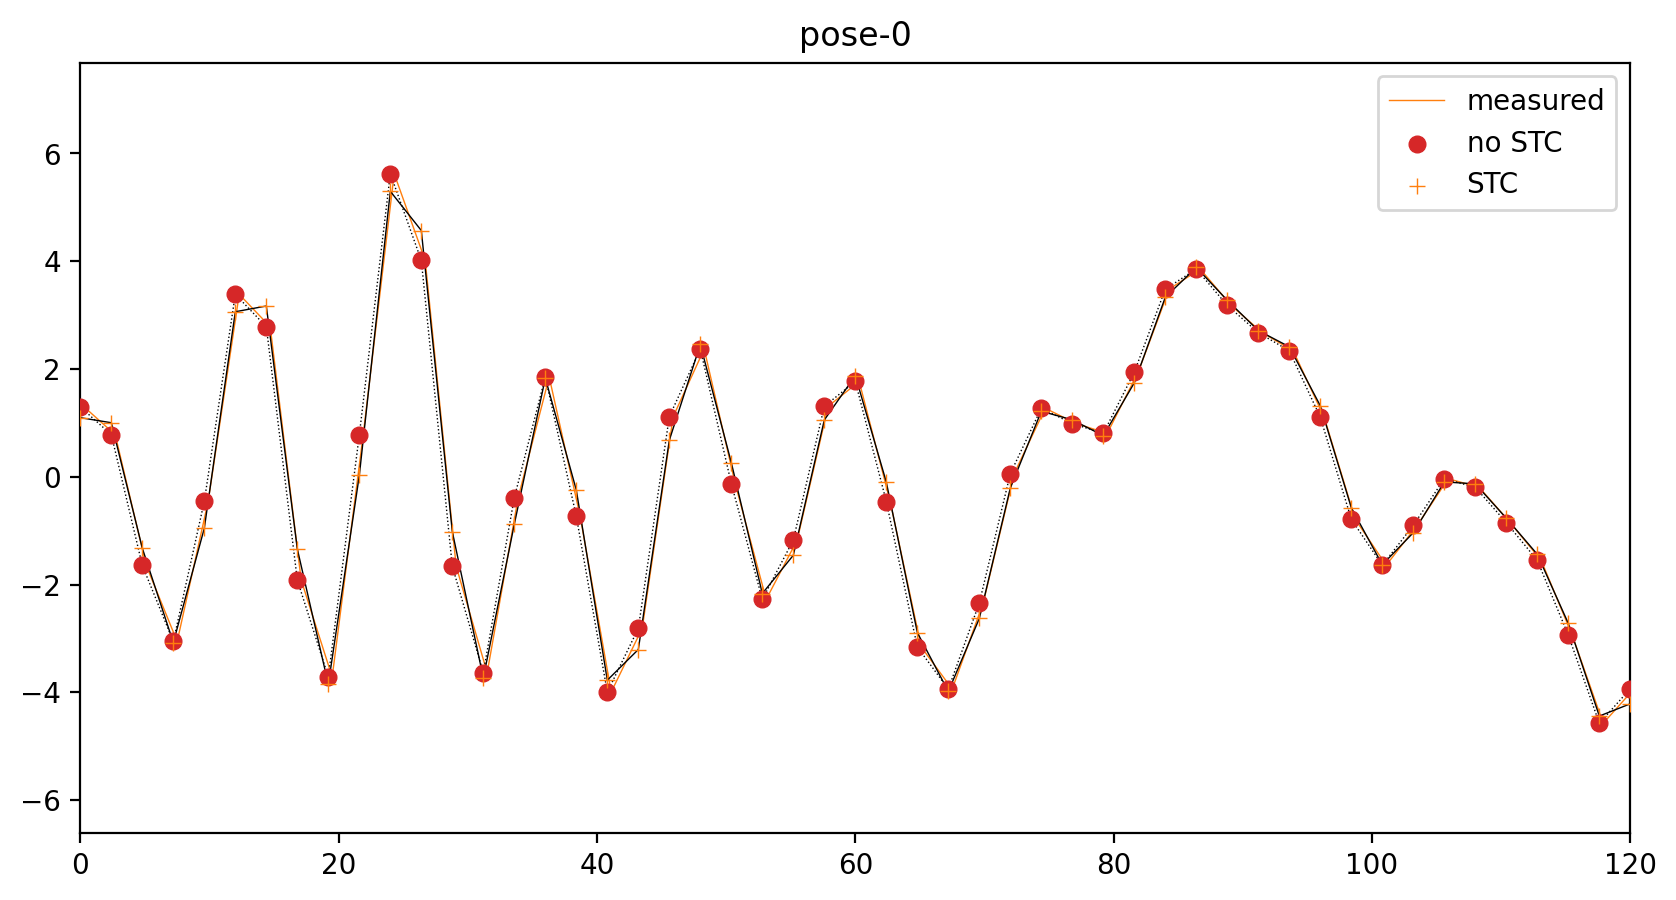

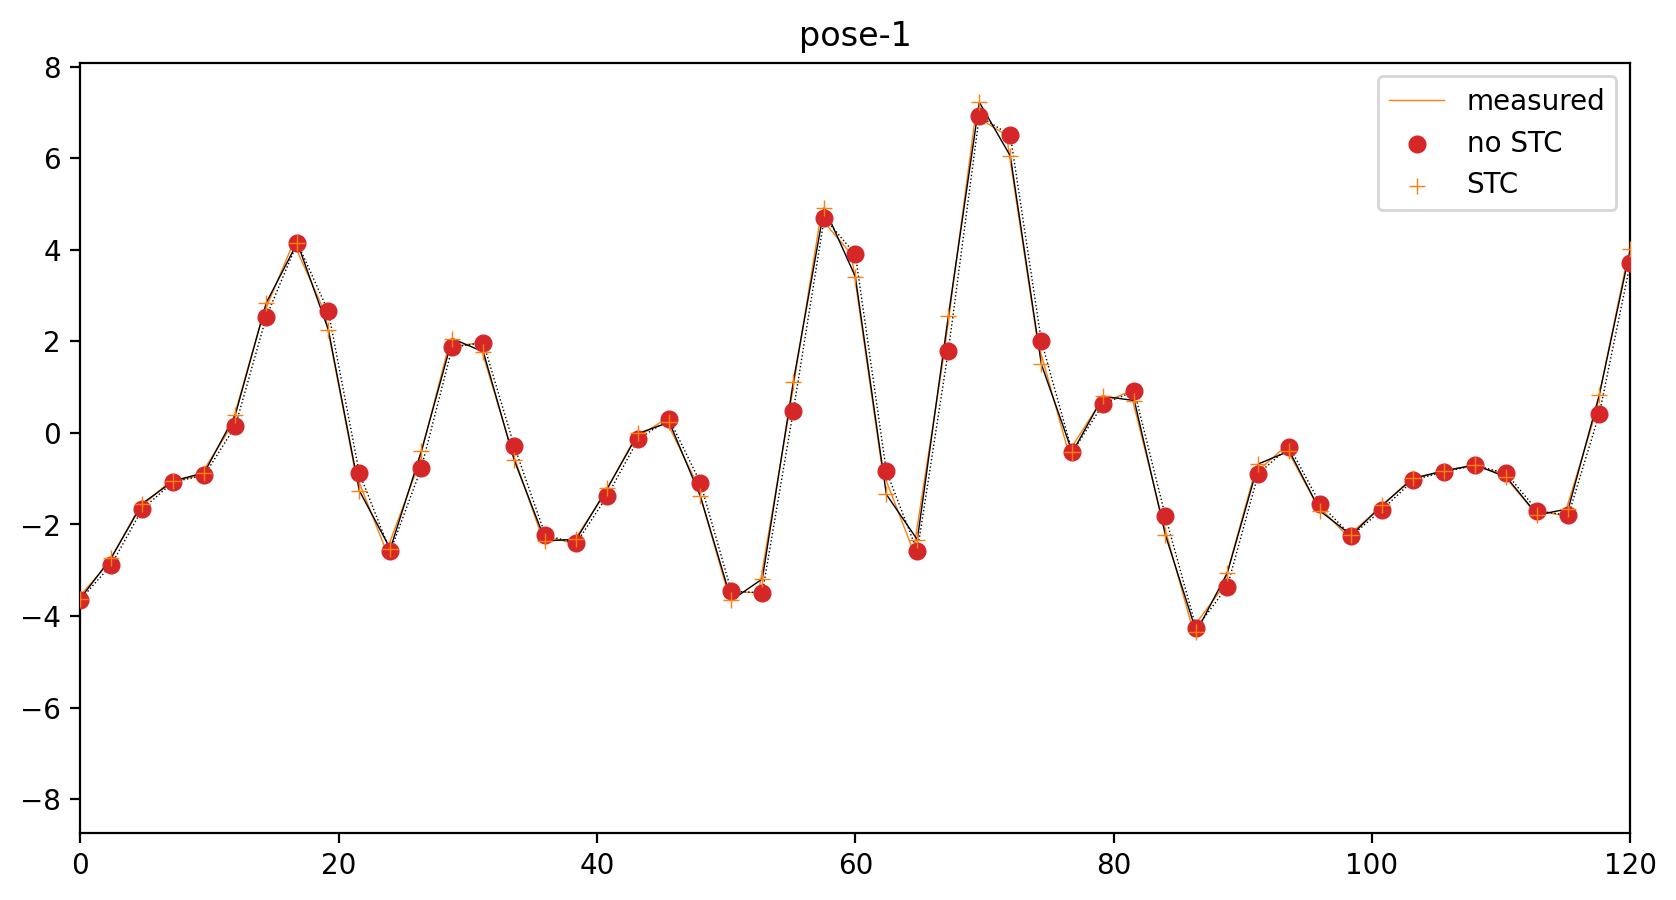

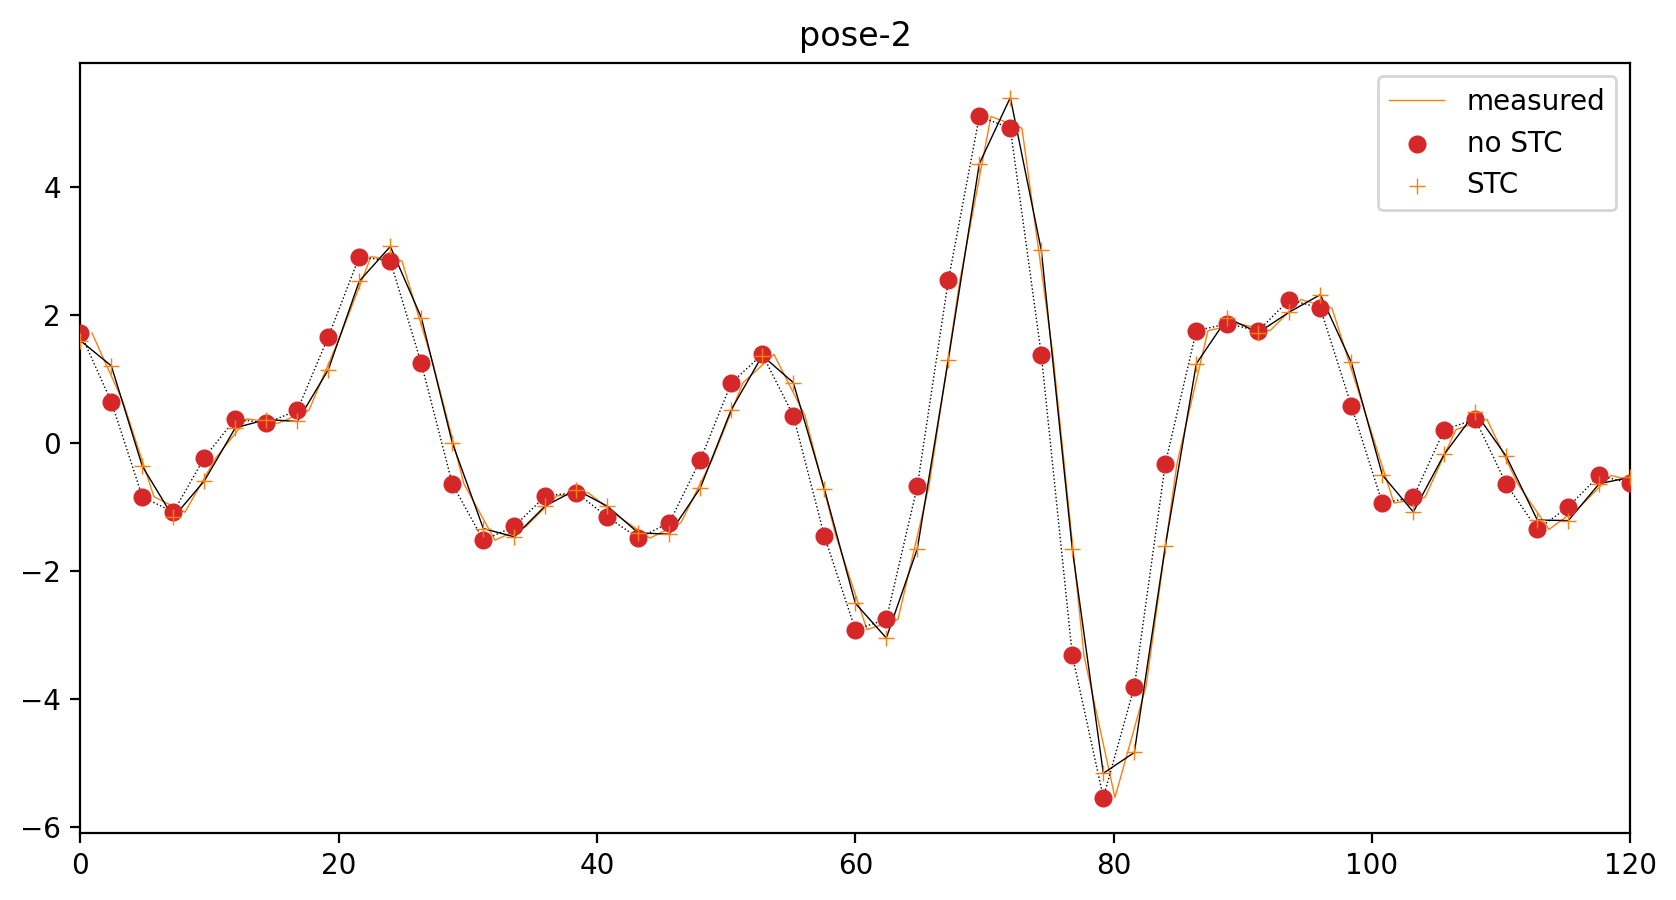

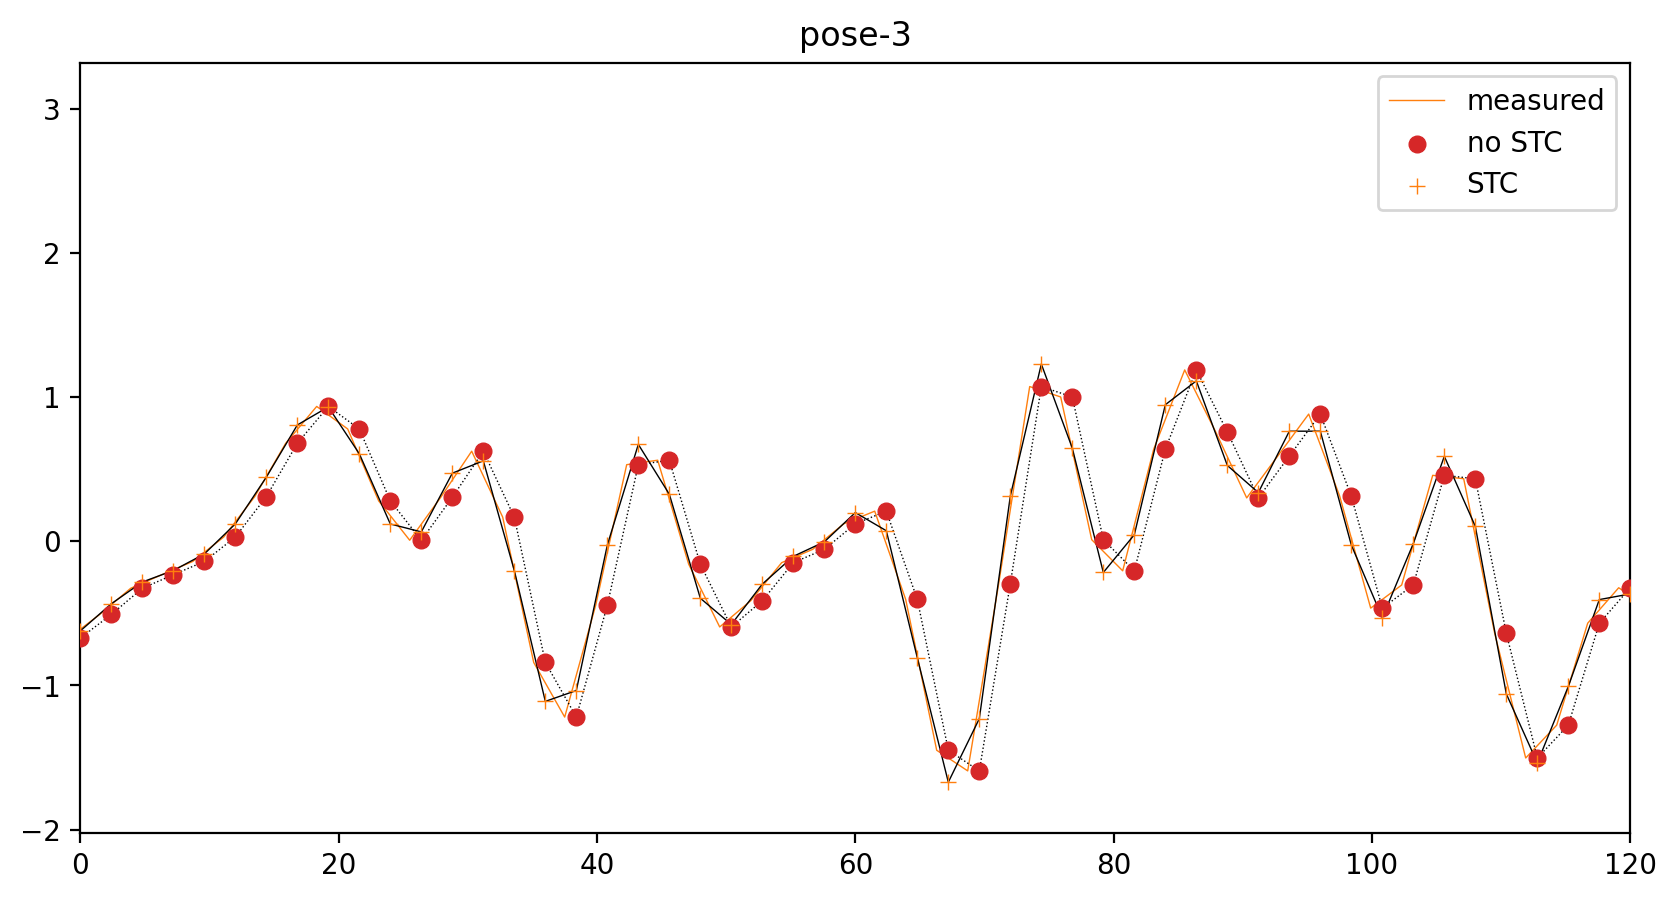

In [8]:

###### Gets file features

subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
if 'run' in file_name.name:
    run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
    title = f'{subject_name} - {session_name} - {run_id}'
    regex_filter = f'{subject_name}.*{session_name}.*{run_id}'
else: 
    title = f'{subject_name} - {session_name}'
    regex_filter = f'{subject_name}.*{session_name}'

###### Load sample mask

sample_mask = np.array(pd.read_table(file_name, header = None)[0][:])

###### Get the data

data_dir = sorted([x for x in data_root.rglob('*') if x.is_file() and re.match(f'^.*{regex_filter}.*{regressor_name}.*Smoothed_pwd.nii.gz', x.name)])

[_,_,_,T] = nib.load(data_dir[0]).shape
time_stamps_ref = np.arange(T)*TR


img_data = []

###### Loop through postions

for pose_id,data_name in enumerate(data_dir):

    # Casoratti matrix
    
    signals = apply_mask(nib.load(data_name), mask_list[pose_id])

    # STC by resamplic 
    
    dt = TR*(time_order[pose_id]-((nb_slice-1)/2))/nb_slice
    resampler = interp1d(time_stamps_ref+dt, signals.T, kind = 'cubic', fill_value="extrapolate")
    signals_stc = resampler(time_stamps_ref).T

    # Back to space x time
    
    img_data.append(
        unmask(signals_stc,mask_list[pose_id]).get_fdata().squeeze()
    )

    #################################### Display
    
    fig,ax = plt.subplots(1,1,dpi = 200, figsize = (10,5))
    
    # measured signal - in measured time
    
    plt.plot(time_stamps_ref+dt, signals[:,1000], lw = 0.5, c = 'C1', ls = '-', zorder = 1, label = 'measured')
    # plt.scatter(time_stamps_ref+dt, signals[:,1000], lw = 0.5, c = 'C1', zorder = 5, label = 'measured')

    # delayed measured signal (the error that we make) - in reference time
    
    plt.plot(time_stamps_ref, signals[:,1000], lw = 0.5, c = 'k', ls = ':', zorder = 1)
    plt.scatter(time_stamps_ref, signals[:,1000], lw = 0.5, c = 'C3', zorder = 5, label = 'no STC')

    # corrected signal - in reference time
    
    plt.plot(time_stamps_ref, signals_stc[:,1000], lw = 0.5, c = 'k', ls = '-', zorder = 1)
    plt.scatter(time_stamps_ref, signals_stc[:,1000], lw = 0.5, marker = '+', c = 'C1', zorder = 5, label = 'STC')
    
    plt.xlim(0,120)
    
    plt.legend()

    plt.title(f'pose-{pose_id}')

    ####################################

###### Output raw image

img_data = np.array(img_data)
[X,Y,Z,T] = img_data.shape

####################################################### OUTPUT

# Chopping

img_out = nib.Nifti1Image(
    img_data[:,:,:,125:-50],
    affine = affine
)

img_out.header.set_zooms([1., 0.1, 0.11, TR])
img_out.header['xyzt_units'] = xyzt_units

In [ ]:
# Change and copy that at the end of previous cell to save you figs

save_dir = Path('/path/to/save/')
save_tag = 'super_image_to_be_saved'

save_name = save_dir / f'{save_tag}.png'
plt.savefig(save_name)
save_name = save_dir / f'{save_tag}.svg'
plt.savefig(save_name)

In [ ]:
fig,ax = plt.subplots(1,1,dpi = 200, figsize = (10,5))

plt.plot(time_stamps_ref, signals[:,1000], lw = 0.5, c = 'k', zorder = 1)
plt.scatter(time_stamps_ref, signals[:,1000], lw = 0.5, c = 'C3', zorder = 5, label = 'no STC')

plt.plot(time_stamps_ref, signals_stc[:,1000], lw = 0.5, c = 'k', ls = ':', zorder = 1)
plt.scatter(time_stamps_ref, signals_stc[:,1000], lw = 0.5, c = 'C1', zorder = 5, label = 'STC')

plt.xlim(0,300)

plt.legend()